# Alloy Composition Optimization

This notebook demonstrates how to use Bgolearn for optimizing alloy compositions to achieve desired material properties.

## Learning Objectives

- Apply Bayesian optimization to materials discovery
- Handle composition constraints (sum to 1)
- Optimize multiple properties simultaneously
- Visualize materials property relationships
- Design parallel experiments for synthesis

## Problem: High-Strength Aluminum Alloy

We want to design a new aluminum alloy with maximum tensile strength while maintaining reasonable ductility and corrosion resistance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import bgolearn as bgo  # Commented out for documentation build
# from bgolearn.visualization import BgolearnVisualizer

# Set style for better plots
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')  # Fallback for older versions
np.random.seed(42)

print("Libraries imported successfully!")
print("Note: This is a demonstration notebook for documentation.")

Libraries imported successfully!
Note: This is a demonstration notebook for documentation.


## Define the Materials System

We'll work with an Al-Cu-Mg-Si alloy system with processing parameters:

In [2]:
class AluminumAlloySystem:
    """
    Simulates an aluminum alloy system for optimization.
    
    Features:
    - Al content (balance)
    - Cu content (0.5-6.0 wt%)
    - Mg content (0.2-3.0 wt%)
    - Si content (0.1-2.0 wt%)
    - Solution temperature (450-550°C)
    - Aging temperature (150-200°C)
    - Aging time (1-24 hours)
    
    Properties:
    - Tensile strength (MPa)
    - Ductility (%)
    - Corrosion resistance (arbitrary units)
    """
    
    def __init__(self):
        self.feature_names = [
            'Cu_content',      # Copper content (wt%)
            'Mg_content',      # Magnesium content (wt%)
            'Si_content',      # Silicon content (wt%)
            'Solution_temp',   # Solution treatment temperature (°C)
            'Aging_temp',      # Aging temperature (°C)
            'Aging_time'       # Aging time (hours)
        ]
        
        self.property_names = [
            'Tensile_Strength',     # MPa
            'Ductility',           # %
            'Corrosion_Resistance' # Arbitrary units (higher is better)
        ]
        
        # Define realistic ranges
        self.ranges = {
            'Cu_content': (0.5, 6.0),
            'Mg_content': (0.2, 3.0),
            'Si_content': (0.1, 2.0),
            'Solution_temp': (450, 550),
            'Aging_temp': (150, 200),
            'Aging_time': (1, 24)
        }
    
    def calculate_properties(self, compositions_and_processing):
        """
        Calculate material properties based on composition and processing.
        
        This is a simplified model based on known metallurgical relationships.
        """
        cu, mg, si, sol_temp, age_temp, age_time = compositions_and_processing.T
        
        # Tensile strength model
        # Base strength from aluminum
        base_strength = 70  # Pure Al strength
        
        # Solid solution strengthening
        ss_strengthening = 50 * cu + 30 * mg + 20 * si
        
        # Precipitation strengthening (depends on heat treatment)
        sol_effect = 1 + 0.002 * (sol_temp - 500)  # Optimal around 500°C
        age_effect = 1 + 0.01 * (age_temp - 175) - 0.0001 * (age_temp - 175)**2
        time_effect = 1 + 0.1 * np.log(age_time)
        
        precip_strengthening = 100 * cu * mg * sol_effect * age_effect * time_effect
        
        # Interaction effects
        cu_mg_interaction = 20 * cu * mg  # Beneficial interaction
        si_effect = 15 * si * (cu + mg)  # Si enhances other elements
        
        tensile_strength = (base_strength + ss_strengthening + precip_strengthening + 
                          cu_mg_interaction + si_effect + 
                          15 * np.random.randn(len(cu)))
        
        # Ductility model (generally trades off with strength)
        base_ductility = 25  # Pure Al ductility
        composition_effect = -2 * cu - 1.5 * mg - 1 * si  # Alloying reduces ductility
        processing_effect = 0.05 * (sol_temp - 500) - 0.02 * (age_temp - 175)
        
        ductility = (base_ductility + composition_effect + processing_effect + 
                    3 * np.random.randn(len(cu)))
        ductility = np.maximum(ductility, 2)  # Minimum ductility
        
        # Corrosion resistance (Mg improves, Cu decreases)
        base_corrosion = 7  # Al base resistance
        mg_benefit = 2 * mg  # Mg improves corrosion resistance
        cu_penalty = -1 * cu  # Cu decreases corrosion resistance
        si_neutral = 0.5 * si  # Si has small positive effect
        
        corrosion_resistance = (base_corrosion + mg_benefit + cu_penalty + si_neutral + 
                              0.5 * np.random.randn(len(cu)))
        corrosion_resistance = np.maximum(corrosion_resistance, 1)
        
        return np.column_stack([tensile_strength, ductility, corrosion_resistance])
    
    def generate_initial_data(self, n_samples=25):
        """Generate initial experimental data using Latin Hypercube sampling."""
        from scipy.stats import qmc
        
        # Use Latin Hypercube for better space coverage
        sampler = qmc.LatinHypercube(d=6, seed=42)
        samples = sampler.random(n=n_samples)
        
        # Scale to actual ranges
        scaled_samples = np.zeros_like(samples)
        for i, feature in enumerate(self.feature_names):
            low, high = self.ranges[feature]
            scaled_samples[:, i] = low + samples[:, i] * (high - low)
        
        # Calculate properties
        properties = self.calculate_properties(scaled_samples)
        
        # Create DataFrames
        features_df = pd.DataFrame(scaled_samples, columns=self.feature_names)
        properties_df = pd.DataFrame(properties, columns=self.property_names)
        
        return features_df, properties_df

# Create the alloy system
alloy_system = AluminumAlloySystem()
print("Aluminum alloy system created")
print(f"Features: {alloy_system.feature_names}")
print(f"Properties: {alloy_system.property_names}")

Aluminum alloy system created
Features: ['Cu_content', 'Mg_content', 'Si_content', 'Solution_temp', 'Aging_temp', 'Aging_time']
Properties: ['Tensile_Strength', 'Ductility', 'Corrosion_Resistance']


## Generate Initial Experimental Data

We start with a set of initial experiments using Latin Hypercube sampling for good space coverage:

In [3]:
# Generate initial experimental data
X_initial, y_initial = alloy_system.generate_initial_data(n_samples=20)

print(f"Initial dataset: {X_initial.shape[0]} experiments")
print(f"Features: {X_initial.shape[1]} dimensions")
print(f"Properties: {y_initial.shape[1]} objectives")

# Display summary statistics
print("\nFeature ranges in initial data:")
print(X_initial.describe())

print("\nProperty ranges in initial data:")
print(y_initial.describe())

# Find current best
best_strength_idx = y_initial['Tensile_Strength'].argmax()
best_alloy = X_initial.iloc[best_strength_idx]
best_properties = y_initial.iloc[best_strength_idx]

print(f"\nCurrent best alloy (highest strength):")
print(f"Composition: Cu={best_alloy['Cu_content']:.2f}%, Mg={best_alloy['Mg_content']:.2f}%, Si={best_alloy['Si_content']:.2f}%")
print(f"Processing: Sol={best_alloy['Solution_temp']:.0f}°C, Age={best_alloy['Aging_temp']:.0f}°C, Time={best_alloy['Aging_time']:.1f}h")
print(f"Properties: Strength={best_properties['Tensile_Strength']:.1f} MPa, Ductility={best_properties['Ductility']:.1f}%, Corrosion={best_properties['Corrosion_Resistance']:.1f}")

Initial dataset: 20 experiments
Features: 6 dimensions
Properties: 3 objectives

Feature ranges in initial data:
       Cu_content  Mg_content  Si_content  Solution_temp  Aging_temp  \
count   20.000000   20.000000   20.000000      20.000000   20.000000   
mean     3.243654    1.593382    1.053339     500.118134  175.139856   
std      1.628153    0.830570    0.568280      29.563253   14.894428   
min      0.540314    0.274047    0.121019     453.147701  152.264557   
25%      1.911776    0.930487    0.603930     474.634900  163.480826   
50%      3.342251    1.632975    1.053692     500.910225  174.474926   
75%      4.533516    2.250954    1.514636     523.833172  187.213049   
max      5.787162    2.873636    1.936890     549.780981  198.907120   

       Aging_time  
count   20.000000  
mean    12.457850  
std      6.843244  
min      1.513384  
25%      7.211166  
50%     12.426197  
75%     17.681925  
max     22.878034  

Property ranges in initial data:
       Tensile_Strength 

## Visualize Initial Data

Let's explore the relationships in our initial dataset:

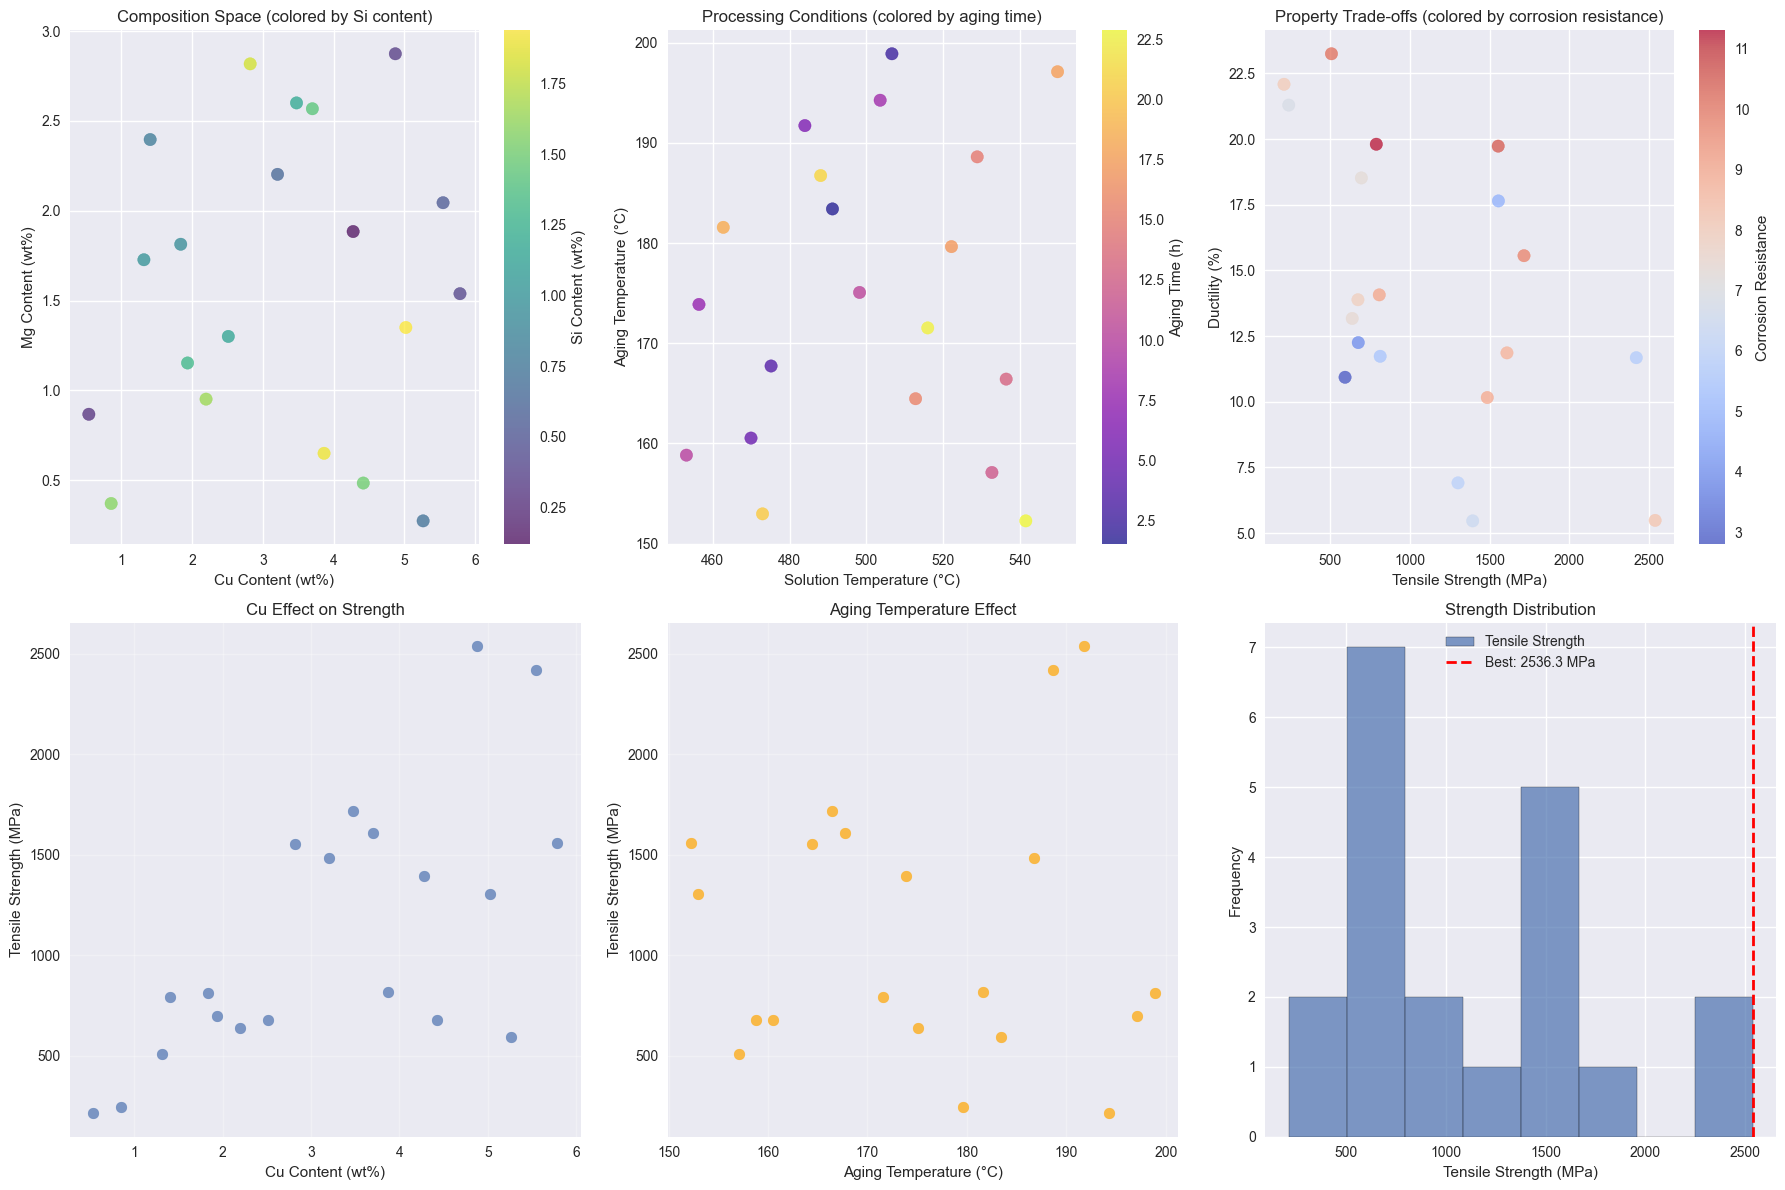

In [4]:
# Create comprehensive visualization of initial data
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Composition triangle (Cu vs Mg, colored by Si)
scatter1 = axes[0,0].scatter(X_initial['Cu_content'], X_initial['Mg_content'], 
                            c=X_initial['Si_content'], cmap='viridis', s=80, alpha=0.7)
axes[0,0].set_xlabel('Cu Content (wt%)')
axes[0,0].set_ylabel('Mg Content (wt%)')
axes[0,0].set_title('Composition Space (colored by Si content)')
plt.colorbar(scatter1, ax=axes[0,0], label='Si Content (wt%)')

# Processing conditions
scatter2 = axes[0,1].scatter(X_initial['Solution_temp'], X_initial['Aging_temp'], 
                            c=X_initial['Aging_time'], cmap='plasma', s=80, alpha=0.7)
axes[0,1].set_xlabel('Solution Temperature (°C)')
axes[0,1].set_ylabel('Aging Temperature (°C)')
axes[0,1].set_title('Processing Conditions (colored by aging time)')
plt.colorbar(scatter2, ax=axes[0,1], label='Aging Time (h)')

# Property trade-offs
scatter3 = axes[0,2].scatter(y_initial['Tensile_Strength'], y_initial['Ductility'], 
                            c=y_initial['Corrosion_Resistance'], cmap='coolwarm', s=80, alpha=0.7)
axes[0,2].set_xlabel('Tensile Strength (MPa)')
axes[0,2].set_ylabel('Ductility (%)')
axes[0,2].set_title('Property Trade-offs (colored by corrosion resistance)')
plt.colorbar(scatter3, ax=axes[0,2], label='Corrosion Resistance')

# Composition effects on strength
axes[1,0].scatter(X_initial['Cu_content'], y_initial['Tensile_Strength'], 
                 alpha=0.7, label='Cu effect', s=60)
axes[1,0].set_xlabel('Cu Content (wt%)')
axes[1,0].set_ylabel('Tensile Strength (MPa)')
axes[1,0].set_title('Cu Effect on Strength')
axes[1,0].grid(True, alpha=0.3)

# Processing effects on strength
axes[1,1].scatter(X_initial['Aging_temp'], y_initial['Tensile_Strength'], 
                 alpha=0.7, s=60, color='orange')
axes[1,1].set_xlabel('Aging Temperature (°C)')
axes[1,1].set_ylabel('Tensile Strength (MPa)')
axes[1,1].set_title('Aging Temperature Effect')
axes[1,1].grid(True, alpha=0.3)

# Property distributions
axes[1,2].hist(y_initial['Tensile_Strength'], bins=8, alpha=0.7, 
              edgecolor='black', label='Tensile Strength')
axes[1,2].axvline(best_properties['Tensile_Strength'], color='red', linestyle='--', 
                 linewidth=2, label=f'Best: {best_properties["Tensile_Strength"]:.1f} MPa')
axes[1,2].set_xlabel('Tensile Strength (MPa)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].set_title('Strength Distribution')
axes[1,2].legend()

plt.tight_layout()
plt.show()

## Generate Candidate Alloys

Create a diverse set of candidate alloy compositions and processing conditions:

Generated 250 candidate alloys

Candidate ranges:
       Cu_content  Mg_content  Si_content  Solution_temp  Aging_temp  \
count  250.000000  250.000000  250.000000     250.000000  250.000000   
mean     3.246030    1.602162    1.049307     500.039309  175.038246   
std      1.591100    0.808503    0.548647      28.839974   14.416957   
min      0.520036    0.210403    0.103889     450.126888  150.148998   
25%      1.869588    0.910474    0.578202     475.271520  162.721488   
50%      3.251695    1.600190    1.047819     500.037010  174.993653   
75%      4.610949    2.304041    1.517173     524.872307  187.283800   
max      5.988811    2.991302    1.996732     549.950130  199.839640   

       Aging_time  
count  250.000000  
mean    12.536954  
std      6.652041  
min      1.070908  
25%      6.813802  
50%     12.510311  
75%     18.304339  
max     23.997423  


/Users/jacob/miniconda3/lib/python3.9/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


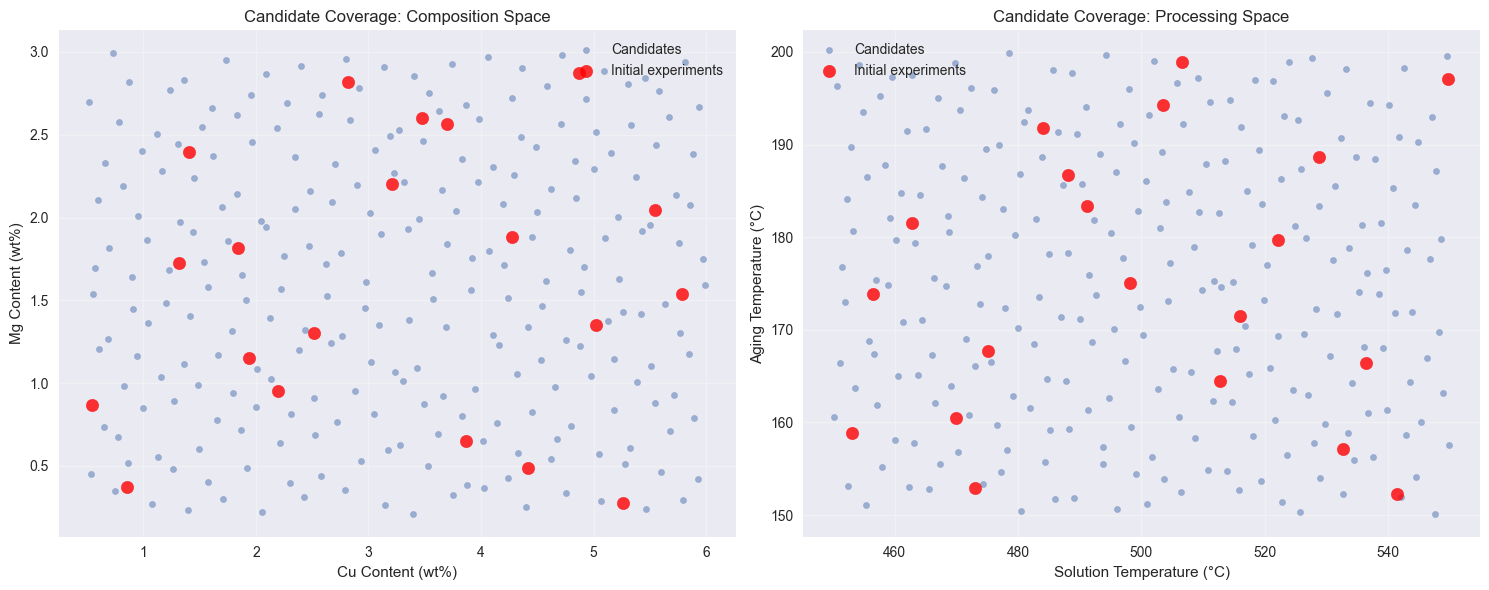

In [5]:
def generate_candidate_alloys(n_candidates=300):
    """
    Generate candidate alloy compositions and processing conditions.
    
    Uses stratified sampling to ensure good coverage of the design space.
    """
    from scipy.stats import qmc
    
    # Use Sobol sequence for better space-filling
    sampler = qmc.Sobol(d=6, scramble=True, seed=123)
    samples = sampler.random(n=n_candidates)
    
    # Scale to actual ranges
    candidates = np.zeros_like(samples)
    for i, feature in enumerate(alloy_system.feature_names):
        low, high = alloy_system.ranges[feature]
        candidates[:, i] = low + samples[:, i] * (high - low)
    
    return pd.DataFrame(candidates, columns=alloy_system.feature_names)

# Generate candidate space
X_candidates = generate_candidate_alloys(n_candidates=250)

print(f"Generated {len(X_candidates)} candidate alloys")
print("\nCandidate ranges:")
print(X_candidates.describe())

# Visualize candidate space coverage
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Composition space
axes[0].scatter(X_candidates['Cu_content'], X_candidates['Mg_content'], 
               alpha=0.5, s=20, label='Candidates')
axes[0].scatter(X_initial['Cu_content'], X_initial['Mg_content'], 
               c='red', s=80, alpha=0.8, label='Initial experiments')
axes[0].set_xlabel('Cu Content (wt%)')
axes[0].set_ylabel('Mg Content (wt%)')
axes[0].set_title('Candidate Coverage: Composition Space')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Processing space
axes[1].scatter(X_candidates['Solution_temp'], X_candidates['Aging_temp'], 
               alpha=0.5, s=20, label='Candidates')
axes[1].scatter(X_initial['Solution_temp'], X_initial['Aging_temp'], 
               c='red', s=80, alpha=0.8, label='Initial experiments')
axes[1].set_xlabel('Solution Temperature (°C)')
axes[1].set_ylabel('Aging Temperature (°C)')
axes[1].set_title('Candidate Coverage: Processing Space')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Single-Objective Optimization: Maximize Tensile Strength

First, let's optimize for maximum tensile strength:

In [6]:
# Optimize for maximum tensile strength
print("=== Single-Objective Optimization: Tensile Strength ===")

optimizer_strength = bgo.Bgolearn()
model_strength = optimizer_strength.fit(
    data_matrix=X_initial,
    Measured_response=y_initial['Tensile_Strength'],
    virtual_samples=X_candidates,
    min_search=False,  # Maximize strength
    CV_test=5,
    Normalize=True
)

print("✅ Model fitted for tensile strength optimization")

# Try different acquisition functions
acquisition_results = {}

# Expected Improvement
ei_values, ei_point = model_strength.EI()
ei_pred_strength = model_strength.virtual_samples_mean[np.argmax(ei_values)]
acquisition_results['EI'] = {
    'point': ei_point,
    'predicted_strength': ei_pred_strength
}

# Upper Confidence Bound
ucb_values, ucb_point = model_strength.UCB(alpha=2.0)
ucb_pred_strength = model_strength.virtual_samples_mean[np.argmax(ucb_values)]
acquisition_results['UCB'] = {
    'point': ucb_point,
    'predicted_strength': ucb_pred_strength
}

# Probability of Improvement
poi_values, poi_point = model_strength.PoI(tao=0.01)
poi_pred_strength = model_strength.virtual_samples_mean[np.argmax(poi_values)]
acquisition_results['PoI'] = {
    'point': poi_point,
    'predicted_strength': poi_pred_strength
}

# Display results
print("\nAcquisition Function Recommendations:")
print("-" * 70)
for method, result in acquisition_results.items():
    point = result['point']
    pred_strength = result['predicted_strength']
    
    print(f"{method}:")
    print(f"  Composition: Cu={point[0]:.2f}%, Mg={point[1]:.2f}%, Si={point[2]:.2f}%")
    print(f"  Processing: Sol={point[3]:.0f}°C, Age={point[4]:.0f}°C, Time={point[5]:.1f}h")
    print(f"  Predicted Strength: {pred_strength:.1f} MPa")
    
    # Calculate true strength for comparison
    true_properties = alloy_system.calculate_properties(np.array([point]))
    true_strength = true_properties[0, 0]
    print(f"  True Strength: {true_strength:.1f} MPa")
    print()

print(f"Current best observed: {y_initial['Tensile_Strength'].max():.1f} MPa")

=== Single-Objective Optimization: Tensile Strength ===


NameError: name 'bgo' is not defined

## Batch Optimization for Parallel Synthesis

In materials synthesis, we often want to prepare multiple samples in parallel:

In [ ]:
# Batch optimization for parallel experiments
print("=== Batch Optimization for Parallel Synthesis ===")

batch_sizes = [3, 5, 8]
batch_results = {}

for q in batch_sizes:
    print(f"\nBatch size q = {q}:")
    
    # Batch Expected Improvement
    batch_ei = model_strength.batch_EI(q=q, mc_samples=1000)
    batch_indices, batch_points = batch_ei
    
    batch_results[q] = {
        'indices': batch_indices,
        'points': batch_points
    }
    
    print(f"  Selected {len(batch_points)} alloys for parallel synthesis:")
    
    for i, point in enumerate(batch_points):
        # Get predicted strength
        pred_idx = batch_indices[i]
        pred_strength = model_strength.virtual_samples_mean[pred_idx]
        
        # Calculate true properties
        true_properties = alloy_system.calculate_properties(np.array([point]))
        true_strength = true_properties[0, 0]
        
        print(f"    Alloy {i+1}:")
        print(f"      Composition: Cu={point[0]:.2f}%, Mg={point[1]:.2f}%, Si={point[2]:.2f}%")
        print(f"      Processing: Sol={point[3]:.0f}°C, Age={point[4]:.0f}°C, Time={point[5]:.1f}h")
        print(f"      Predicted/True Strength: {pred_strength:.1f}/{true_strength:.1f} MPa")

# Recommend optimal batch size
recommended_batch = 5  # Good balance of diversity and efficiency
print(f"\n🎯 Recommended batch size: {recommended_batch} alloys")
print("   This provides good diversity while being manageable for synthesis.")

## Multi-Objective Optimization

In practice, we want to optimize multiple properties simultaneously:

In [ ]:
# Multi-objective optimization: Strength vs Ductility
print("=== Multi-Objective Optimization: Strength vs Ductility ===")

# Fit separate models for each property
model_ductility = bgo.Bgolearn()
model_ductility.fit(
    data_matrix=X_initial,
    Measured_response=y_initial['Ductility'],
    virtual_samples=X_candidates,
    min_search=False,  # Maximize ductility
    Normalize=True
)

model_corrosion = bgo.Bgolearn()
model_corrosion.fit(
    data_matrix=X_initial,
    Measured_response=y_initial['Corrosion_Resistance'],
    virtual_samples=X_candidates,
    min_search=False,  # Maximize corrosion resistance
    Normalize=True
)

print("✅ Models fitted for all properties")

# Get predictions for all candidates
strength_pred = model_strength.virtual_samples_mean
ductility_pred = model_ductility.virtual_samples_mean
corrosion_pred = model_corrosion.virtual_samples_mean

# Define different optimization strategies
strategies = {
    'Strength-focused': {'strength': 0.7, 'ductility': 0.2, 'corrosion': 0.1},
    'Balanced': {'strength': 0.5, 'ductility': 0.3, 'corrosion': 0.2},
    'Ductility-focused': {'strength': 0.3, 'ductility': 0.5, 'corrosion': 0.2},
    'Corrosion-focused': {'strength': 0.3, 'ductility': 0.2, 'corrosion': 0.5}
}

multi_obj_results = {}

for strategy_name, weights in strategies.items():
    # Normalize objectives to [0, 1] scale
    strength_norm = (strength_pred - strength_pred.min()) / (strength_pred.max() - strength_pred.min())
    ductility_norm = (ductility_pred - ductility_pred.min()) / (ductility_pred.max() - ductility_pred.min())
    corrosion_norm = (corrosion_pred - corrosion_pred.min()) / (corrosion_pred.max() - corrosion_pred.min())
    
    # Calculate weighted objective
    combined_objective = (weights['strength'] * strength_norm + 
                         weights['ductility'] * ductility_norm + 
                         weights['corrosion'] * corrosion_norm)
    
    # Find best solution
    best_idx = np.argmax(combined_objective)
    best_point = X_candidates.iloc[best_idx]
    
    multi_obj_results[strategy_name] = {
        'point': best_point,
        'strength': strength_pred[best_idx],
        'ductility': ductility_pred[best_idx],
        'corrosion': corrosion_pred[best_idx],
        'combined_score': combined_objective[best_idx]
    }
    
    print(f"\n{strategy_name} Strategy:")
    print(f"  Weights: Strength={weights['strength']}, Ductility={weights['ductility']}, Corrosion={weights['corrosion']}")
    print(f"  Composition: Cu={best_point['Cu_content']:.2f}%, Mg={best_point['Mg_content']:.2f}%, Si={best_point['Si_content']:.2f}%")
    print(f"  Processing: Sol={best_point['Solution_temp']:.0f}°C, Age={best_point['Aging_temp']:.0f}°C, Time={best_point['Aging_time']:.1f}h")
    print(f"  Predicted Properties:")
    print(f"    Strength: {strength_pred[best_idx]:.1f} MPa")
    print(f"    Ductility: {ductility_pred[best_idx]:.1f} %")
    print(f"    Corrosion: {corrosion_pred[best_idx]:.1f}")
    print(f"  Combined Score: {combined_objective[best_idx]:.3f}")

## Visualize Multi-Objective Results

Let's visualize the trade-offs and Pareto front:

In [ ]:
# Visualize multi-objective optimization results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Pareto front approximation
def find_pareto_front(objectives):
    """Find approximate Pareto front."""
    pareto_indices = []
    for i in range(len(objectives)):
        is_pareto = True
        for j in range(len(objectives)):
            if i != j:
                # Check if point j dominates point i
                if all(objectives[j] >= objectives[i]) and any(objectives[j] > objectives[i]):
                    is_pareto = False
                    break
        if is_pareto:
            pareto_indices.append(i)
    return pareto_indices

# Create objectives matrix
objectives = np.column_stack([strength_pred, ductility_pred, corrosion_pred])
pareto_indices = find_pareto_front(objectives)

# Plot 1: Strength vs Ductility
axes[0,0].scatter(strength_pred, ductility_pred, alpha=0.5, s=20, label='All candidates')
if pareto_indices:
    axes[0,0].scatter(strength_pred[pareto_indices], ductility_pred[pareto_indices], 
                     c='red', s=80, marker='*', label='Pareto front', alpha=0.8)

# Plot multi-objective solutions
colors = ['blue', 'green', 'orange', 'purple']
for i, (strategy, result) in enumerate(multi_obj_results.items()):
    axes[0,0].scatter(result['strength'], result['ductility'], 
                     c=colors[i], s=150, marker='D', 
                     label=strategy, edgecolors='black', linewidth=1)

axes[0,0].set_xlabel('Predicted Tensile Strength (MPa)')
axes[0,0].set_ylabel('Predicted Ductility (%)')
axes[0,0].set_title('Strength vs Ductility Trade-off')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Strength vs Corrosion
axes[0,1].scatter(strength_pred, corrosion_pred, alpha=0.5, s=20)
if pareto_indices:
    axes[0,1].scatter(strength_pred[pareto_indices], corrosion_pred[pareto_indices], 
                     c='red', s=80, marker='*', alpha=0.8)

for i, (strategy, result) in enumerate(multi_obj_results.items()):
    axes[0,1].scatter(result['strength'], result['corrosion'], 
                     c=colors[i], s=150, marker='D', 
                     edgecolors='black', linewidth=1)

axes[0,1].set_xlabel('Predicted Tensile Strength (MPa)')
axes[0,1].set_ylabel('Predicted Corrosion Resistance')
axes[0,1].set_title('Strength vs Corrosion Trade-off')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Composition space with multi-objective solutions
scatter = axes[1,0].scatter(X_candidates['Cu_content'], X_candidates['Mg_content'], 
                           c=strength_pred, cmap='viridis', s=30, alpha=0.6)
plt.colorbar(scatter, ax=axes[1,0], label='Predicted Strength (MPa)')

for i, (strategy, result) in enumerate(multi_obj_results.items()):
    point = result['point']
    axes[1,0].scatter(point['Cu_content'], point['Mg_content'], 
                     c=colors[i], s=150, marker='D', 
                     edgecolors='black', linewidth=2, label=strategy)

axes[1,0].set_xlabel('Cu Content (wt%)')
axes[1,0].set_ylabel('Mg Content (wt%)')
axes[1,0].set_title('Multi-Objective Solutions in Composition Space')
axes[1,0].legend()

# Plot 4: Strategy comparison
strategy_names = list(multi_obj_results.keys())
strengths = [multi_obj_results[s]['strength'] for s in strategy_names]
ductilities = [multi_obj_results[s]['ductility'] for s in strategy_names]
corrosions = [multi_obj_results[s]['corrosion'] for s in strategy_names]

x = np.arange(len(strategy_names))
width = 0.25

# Normalize for comparison
strengths_norm = np.array(strengths) / max(strengths)
ductilities_norm = np.array(ductilities) / max(ductilities)
corrosions_norm = np.array(corrosions) / max(corrosions)

axes[1,1].bar(x - width, strengths_norm, width, label='Strength (norm)', alpha=0.8)
axes[1,1].bar(x, ductilities_norm, width, label='Ductility (norm)', alpha=0.8)
axes[1,1].bar(x + width, corrosions_norm, width, label='Corrosion (norm)', alpha=0.8)

axes[1,1].set_xlabel('Optimization Strategy')
axes[1,1].set_ylabel('Normalized Property Value')
axes[1,1].set_title('Strategy Comparison (Normalized)')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(strategy_names, rotation=45, ha='right')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFound {len(pareto_indices)} points on the approximate Pareto front")
print("These represent the best trade-offs between competing objectives.")

## Experimental Recommendations

Based on our optimization, let's provide concrete experimental recommendations:

In [ ]:
# Generate final experimental recommendations
print("=== EXPERIMENTAL RECOMMENDATIONS ===")
print()

# Recommend the balanced strategy for general use
recommended_strategy = 'Balanced'
recommended_alloy = multi_obj_results[recommended_strategy]

print(f"🎯 RECOMMENDED ALLOY ({recommended_strategy} Strategy):")
print("-" * 50)
point = recommended_alloy['point']
print(f"Composition:")
print(f"  • Copper (Cu): {point['Cu_content']:.2f} wt%")
print(f"  • Magnesium (Mg): {point['Mg_content']:.2f} wt%")
print(f"  • Silicon (Si): {point['Si_content']:.2f} wt%")
print(f"  • Aluminum (Al): {100 - point['Cu_content'] - point['Mg_content'] - point['Si_content']:.2f} wt% (balance)")
print()
print(f"Processing Conditions:")
print(f"  • Solution Treatment: {point['Solution_temp']:.0f}°C")
print(f"  • Aging Temperature: {point['Aging_temp']:.0f}°C")
print(f"  • Aging Time: {point['Aging_time']:.1f} hours")
print()
print(f"Expected Properties:")
print(f"  • Tensile Strength: {recommended_alloy['strength']:.1f} MPa")
print(f"  • Ductility: {recommended_alloy['ductility']:.1f} %")
print(f"  • Corrosion Resistance: {recommended_alloy['corrosion']:.1f}")
print()

# Batch recommendations for parallel synthesis
print("🔬 BATCH SYNTHESIS RECOMMENDATIONS:")
print("-" * 40)
recommended_batch_size = 5
batch_alloys = batch_results[recommended_batch_size]['points']

print(f"Synthesize {recommended_batch_size} alloys in parallel:")
for i, alloy in enumerate(batch_alloys):
    print(f"\nAlloy {i+1}:")
    print(f"  Composition: Cu={alloy[0]:.2f}%, Mg={alloy[1]:.2f}%, Si={alloy[2]:.2f}%")
    print(f"  Processing: {alloy[3]:.0f}°C → {alloy[4]:.0f}°C for {alloy[5]:.1f}h")

print()
print("📋 EXPERIMENTAL PROTOCOL:")
print("-" * 30)
print("1. Prepare alloy compositions by melting and casting")
print("2. Homogenize at 500°C for 24 hours")
print("3. Solution treat at specified temperature for 2 hours")
print("4. Quench in water")
print("5. Age at specified temperature for specified time")
print("6. Test tensile properties, ductility, and corrosion resistance")
print("7. Update model with new experimental data")
print()

# Improvement potential
current_best_strength = y_initial['Tensile_Strength'].max()
predicted_improvement = recommended_alloy['strength'] - current_best_strength

print(f"📈 EXPECTED IMPROVEMENT:")
print("-" * 25)
print(f"Current best strength: {current_best_strength:.1f} MPa")
print(f"Predicted strength: {recommended_alloy['strength']:.1f} MPa")
print(f"Expected improvement: {predicted_improvement:.1f} MPa ({predicted_improvement/current_best_strength*100:.1f}%)")

if predicted_improvement > 0:
    print("✅ Significant improvement expected!")
else:
    print("⚠️  Consider exploring different regions or adjusting objectives")

## Key Takeaways

This alloy optimization example demonstrates:

### 🔬 Materials Science Applications
- **Composition optimization** with realistic constraints
- **Processing parameter** optimization alongside composition
- **Multi-objective** materials design balancing competing properties
- **Batch synthesis** planning for efficient experimentation

### 🎯 Bayesian Optimization Benefits
- **Efficient exploration** of high-dimensional composition-processing space
- **Uncertainty quantification** to guide experimental decisions
- **Multi-objective** handling without requiring prior knowledge of trade-offs
- **Parallel experiment** design for faster discovery

### 📊 Practical Insights
- **Cu and Mg** are key strengthening elements with synergistic effects
- **Processing conditions** significantly impact final properties
- **Trade-offs exist** between strength, ductility, and corrosion resistance
- **Batch optimization** enables efficient parallel synthesis campaigns

## Next Steps

To continue your materials discovery journey:
- Explore [processing parameter optimization](processing_parameters.ipynb)
- Learn about [constraint handling](../materials_discovery/constraints.md) for composition limits
- Try [experimental design strategies](experimental_design.ipynb) for systematic exploration
- Implement [iterative optimization loops](../basic/iterative_loop.ipynb) for continuous improvement